In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Jeżeli notebook jest w folderze notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_RAW = PROJECT_ROOT / "data" / "raw"

df_path = DATA_PROCESSED / "df_model_clean_v1.parquet"
rapping_path = DATA_PROCESSED / "rapping_features_v1.parquet"
tag_classification_path = DATA_PROCESSED / "tag_classification_v1.xlsx"

df = pd.read_parquet(df_path)
rapping = pd.read_parquet(rapping_path)
tag_classification = pd.read_excel(tag_classification_path)

print(df.shape)
print(df.index.min(), "→", df.index.max())
print(rapping.shape)
print(tag_classification.shape)

(210644, 76)
2025-06-30 00:00:00 → 2025-08-01 00:00:00
(210644, 3)
(76, 7)


In [2]:
TARGET_COL = "008A01345"  # pył za ESP

U_COLS = {
    "U1": "008A02289",  # napięcie wtórne sekcja 1A
    "U2": "008A02290",  # napięcie wtórne sekcja 2A
    "U3": "008A02291",  # napięcie wtórne sekcja 3A
}

I_COLS = {
    "I1": "008A02267",  # prąd wtórny sekcja 1A
    "I2": "008A02268",  # prąd wtórny sekcja 2A
    "I3": "008A02269",  # prąd wtórny sekcja 3A
}

P_COLS = {
    "P1": "008A02273",  # moc sekcja 1A
    "P2": "008A02274",  # moc sekcja 2A
    "P3": "008A02275",  # moc sekcja 3A
}

RAPPING_TIME_COL = "minutes_since_rapping_3_collecting_start_0_5"
RAPPING_FLAG_COL = "is_within_5min_after_rapping_3_collecting"

required_cols = [TARGET_COL] + list(U_COLS.values()) + list(I_COLS.values()) + list(P_COLS.values())

missing = [col for col in required_cols if col not in df.columns]
missing

[]

In [3]:
df_eco = df.copy()

rapping_cols = [RAPPING_TIME_COL, RAPPING_FLAG_COL]

df_eco = df_eco.join(
    rapping[rapping_cols],
    how="left"
)

df_eco[rapping_cols].head()

,minutes_since_rapping_3_collecting_start_0_5,is_within_5min_after_rapping_3_collecting
timestamp,,
2025-06-30 00:00:00,-1.0,0
2025-06-30 00:00:10,-1.0,0
2025-06-30 00:00:20,-1.0,0
2025-06-30 00:00:30,-1.0,0
2025-06-30 00:00:40,-1.0,0


In [4]:
df_eco["P_total"] = df_eco[list(P_COLS.values())].sum(axis=1)
df_eco["U_mean"] = df_eco[list(U_COLS.values())].mean(axis=1)
df_eco["U_sum"] = df_eco[list(U_COLS.values())].sum(axis=1)

for sec in ["1", "2", "3"]:
    u_col = U_COLS[f"U{sec}"]
    i_col = I_COLS[f"I{sec}"]
    p_col = P_COLS[f"P{sec}"]

    df_eco[f"P{sec}_calc"] = df_eco[u_col] * df_eco[i_col] / 1000
    df_eco[f"P{sec}_error"] = df_eco[f"P{sec}_calc"] - df_eco[p_col]

df_eco["P_total_calc"] = df_eco[["P1_calc", "P2_calc", "P3_calc"]].sum(axis=1)
df_eco["P_total_error"] = df_eco["P_total_calc"] - df_eco["P_total"]

df_eco[
    [TARGET_COL, "P_total", "P_total_calc", "P_total_error", "U_mean"]
].describe()

,008A01345,P_total,P_total_calc,P_total_error,U_mean
count,210644.000000,210644.000000,210644.000000,210644.000000,210644.000000
mean,11.149162,39.890049,39.496097,-0.393952,42.333769
std,4.822527,9.572117,9.493744,0.195468,1.406155
min,2.000000,31.200000,30.872000,-3.765999,37.333333
25%,9.000000,37.900001,37.504000,-0.514000,41.666667
50%,11.000000,38.299999,37.916000,-0.396000,42.000000
75%,13.000000,38.700001,38.341000,-0.276000,42.333333
max,101.000000,288.699997,287.868000,4.168003,67.666667


In [5]:
power_validation = []

for sec in ["1", "2", "3"]:
    p_col = P_COLS[f"P{sec}"]
    p_calc_col = f"P{sec}_calc"

    power_validation.append({
        "section": sec,
        "measured_power_col": p_col,
        "corr": df_eco[p_col].corr(df_eco[p_calc_col]),
        "mae_kw": (df_eco[p_col] - df_eco[p_calc_col]).abs().mean(),
        "bias_kw": (df_eco[p_calc_col] - df_eco[p_col]).mean(),
        "measured_mean_kw": df_eco[p_col].mean(),
        "calc_mean_kw": df_eco[p_calc_col].mean(),
    })

power_validation = pd.DataFrame(power_validation)
power_validation

,section,measured_power_col,corr,mae_kw,bias_kw,measured_mean_kw,calc_mean_kw
0,1,008A02273,0.999445,0.129637,-0.125743,14.549759,14.424016
1,2,008A02274,0.999518,0.140359,-0.129159,12.960008,12.830849
2,3,008A02275,0.999631,0.148346,-0.139050,12.380282,12.241233


In [6]:
samples_per_min = 6

df_eco["dust_delta_1min"] = df_eco[TARGET_COL] - df_eco[TARGET_COL].shift(1 * samples_per_min)
df_eco["dust_delta_3min"] = df_eco[TARGET_COL] - df_eco[TARGET_COL].shift(3 * samples_per_min)

df_eco["P_delta_1min"] = df_eco["P_total"] - df_eco["P_total"].shift(1 * samples_per_min)
df_eco["P_delta_3min"] = df_eco["P_total"] - df_eco["P_total"].shift(3 * samples_per_min)

df_eco["U_delta_1min"] = df_eco["U_mean"] - df_eco["U_mean"].shift(1 * samples_per_min)
df_eco["U_delta_3min"] = df_eco["U_mean"] - df_eco["U_mean"].shift(3 * samples_per_min)

df_eco[
    ["dust_delta_3min", "P_delta_3min", "U_delta_3min"]
].describe()

,dust_delta_3min,P_delta_3min,U_delta_3min
count,210626.000000,210626.000000,210626.000000
mean,0.000418,0.000118,0.000087
std,5.735102,7.560952,1.317499
min,-86.000000,-69.099995,-7.333333
25%,-1.000000,-0.100000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.100000,0.000000
max,83.000000,212.000001,19.000000


In [7]:
def lagged_corr(x, y, max_lag_samples):
    """
    corr(x(t), y(t + lag))
    lag > 0 oznacza, że x poprzedza y.
    """
    rows = []

    for lag in range(-max_lag_samples, max_lag_samples + 1):
        if lag < 0:
            x_lag = x.shift(-lag)
            y_lag = y
        elif lag > 0:
            x_lag = x
            y_lag = y.shift(-lag)
        else:
            x_lag = x
            y_lag = y

        valid = x_lag.notna() & y_lag.notna()

        rows.append({
            "lag_samples": lag,
            "lag_minutes": lag / samples_per_min,
            "corr": x_lag[valid].corr(y_lag[valid]),
            "n": valid.sum(),
        })

    return pd.DataFrame(rows)


max_lag_min = 10
max_lag_samples = max_lag_min * samples_per_min

corr_dust_P_delta = lagged_corr(
    df_eco["dust_delta_3min"],
    df_eco["P_delta_3min"],
    max_lag_samples=max_lag_samples
)

corr_dust_U_delta = lagged_corr(
    df_eco["dust_delta_3min"],
    df_eco["U_delta_3min"],
    max_lag_samples=max_lag_samples
)

best_P = corr_dust_P_delta.loc[corr_dust_P_delta["corr"].idxmax()]
best_U = corr_dust_U_delta.loc[corr_dust_U_delta["corr"].idxmax()]

best_P, best_U

(lag_samples        -8.000000
 lag_minutes        -1.333333
 corr                0.567288
 n              210618.000000
 Name: 52, dtype: float64,
 lag_samples        -8.000000
 lag_minutes        -1.333333
 corr                0.555643
 n              210618.000000
 Name: 52, dtype: float64)

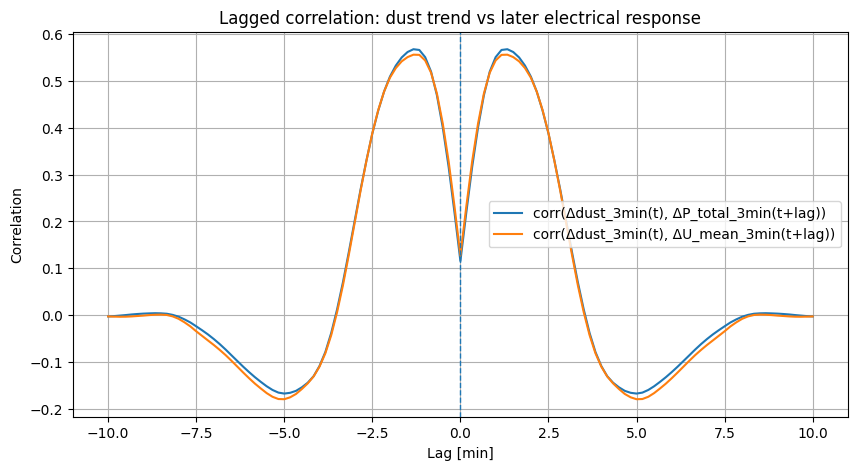

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    corr_dust_P_delta["lag_minutes"],
    corr_dust_P_delta["corr"],
    label="corr(Δdust_3min(t), ΔP_total_3min(t+lag))"
)

plt.plot(
    corr_dust_U_delta["lag_minutes"],
    corr_dust_U_delta["corr"],
    label="corr(Δdust_3min(t), ΔU_mean_3min(t+lag))"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag [min]")
plt.ylabel("Correlation")
plt.title("Lagged correlation: dust trend vs later electrical response")
plt.legend()
plt.grid(True)
plt.show()

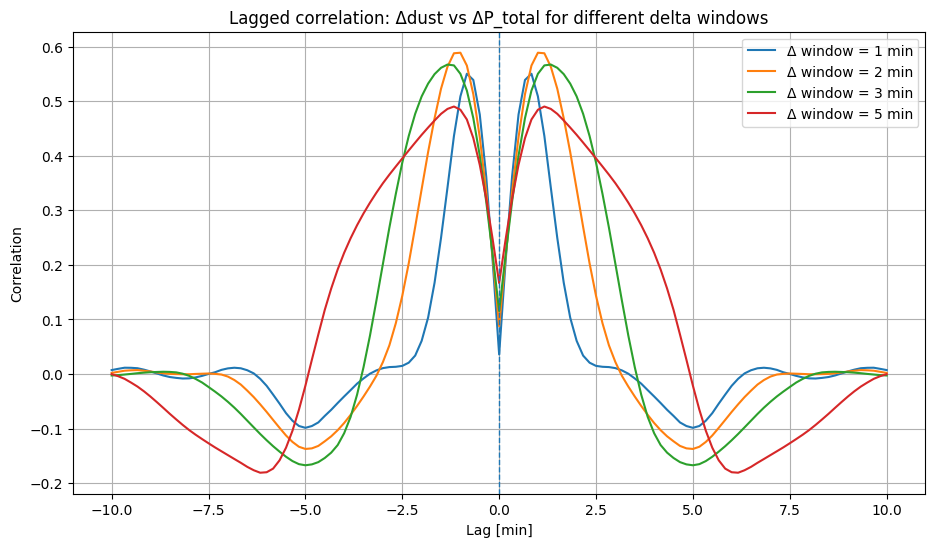

,delta_window_min,best_lag_min,best_corr,n
0,1,-0.833333,0.550426,210633.0
1,2,-1.000000,0.588956,210626.0
2,3,-1.333333,0.567288,210618.0
3,5,-1.166667,0.490355,210607.0


In [9]:
delta_windows_min = [1, 2, 3, 5]
lag_results = []

plt.figure(figsize=(11, 6))

for window_min in delta_windows_min:
    shift_n = window_min * samples_per_min
    
    dust_delta = df_eco[TARGET_COL] - df_eco[TARGET_COL].shift(shift_n)
    p_delta = df_eco["P_total"] - df_eco["P_total"].shift(shift_n)
    
    corr_df = lagged_corr(
        dust_delta,
        p_delta,
        max_lag_samples=10 * samples_per_min
    )
    
    best = corr_df.loc[corr_df["corr"].idxmax()]
    
    lag_results.append({
        "delta_window_min": window_min,
        "best_lag_min": best["lag_minutes"],
        "best_corr": best["corr"],
        "n": best["n"],
    })
    
    plt.plot(
        corr_df["lag_minutes"],
        corr_df["corr"],
        label=f"Δ window = {window_min} min"
    )

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag [min]")
plt.ylabel("Correlation")
plt.title("Lagged correlation: Δdust vs ΔP_total for different delta windows")
plt.legend()
plt.grid(True)
plt.show()

lag_results = pd.DataFrame(lag_results)
lag_results

In [10]:
rapping.columns

Index(['rapping_3_collecting_start', 'minutes_since_rapping_3_collecting_start_0_5', 'is_within_5min_after_rapping_3_collecting'], dtype='object')

In [11]:
RAPPING_START_COL = "rapping_3_collecting_start"

# Dołączamy start strzepywania, jeśli jeszcze nie został dołączony
if RAPPING_START_COL not in df_eco.columns:
    df_eco = df_eco.join(rapping[[RAPPING_START_COL]], how="left")

rapping_starts = df_eco.index[df_eco[RAPPING_START_COL] == 1]

print("Number of rapping starts:", len(rapping_starts))
print("First events:")
print(rapping_starts[:10])

Number of rapping starts: 423
First events:
DatetimeIndex(['2025-06-30 00:51:00', '2025-06-30 02:13:50', '2025-06-30 03:36:30', '2025-06-30 04:59:20', '2025-06-30 06:22:00', '2025-06-30 07:47:00', '2025-06-30 09:09:40', '2025-06-30 10:32:30',
               '2025-06-30 11:55:10', '2025-06-30 13:18:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)


In [12]:
pre_min = 5
post_min = 15

pre_samples = pre_min * samples_per_min
post_samples = post_min * samples_per_min

signals_for_event = [
    TARGET_COL,
    "P_total",
    "U_mean",
    "U_sum",
    *list(U_COLS.values()),
    *list(I_COLS.values()),
    *list(P_COLS.values()),
]

event_windows = []

for event_id, event_time in enumerate(rapping_starts):
    event_pos = df_eco.index.get_loc(event_time)
    
    start_pos = event_pos - pre_samples
    end_pos = event_pos + post_samples
    
    if start_pos < 0 or end_pos >= len(df_eco):
        continue
    
    window = df_eco.iloc[start_pos:end_pos + 1][signals_for_event].copy()
    window["event_id"] = event_id
    window["event_time"] = event_time
    
    # czas względem strzepywania w minutach
    relative_samples = np.arange(-pre_samples, post_samples + 1)
    window["t_rel_min"] = relative_samples / samples_per_min
    
    event_windows.append(window)

events_df = pd.concat(event_windows, axis=0)

print(events_df.shape)
events_df.head()

(51183, 16)


,008A01345,P_total,U_mean,U_sum,008A02289,008A02290,008A02291,008A02267,008A02268,008A02269,008A02273,008A02274,008A02275,event_id,event_time,t_rel_min
timestamp,,,,,,,,,,,,,,,,
2025-06-30 00:46:00,10.0,37.600000,41.0,123.0,47.0,39.0,37.0,296.0,306.0,304.0,14.1,12.2,11.3,0,2025-06-30 00:51:00,-5.000000
2025-06-30 00:46:10,9.0,37.300000,41.0,123.0,47.0,39.0,37.0,296.0,301.0,304.0,14.1,11.9,11.3,0,2025-06-30 00:51:00,-4.833333
2025-06-30 00:46:20,9.0,37.200000,41.0,123.0,47.0,39.0,37.0,294.0,301.0,304.0,14.0,11.9,11.3,0,2025-06-30 00:51:00,-4.666667
2025-06-30 00:46:30,9.0,37.400001,41.0,123.0,47.0,39.0,37.0,294.0,303.0,304.0,14.0,12.1,11.3,0,2025-06-30 00:51:00,-4.500000
2025-06-30 00:46:40,9.0,37.500000,41.0,123.0,47.0,39.0,37.0,294.0,306.0,304.0,14.0,12.2,11.3,0,2025-06-30 00:51:00,-4.333333


In [13]:
avg_response = (
    events_df
    .groupby("t_rel_min")[signals_for_event]
    .mean()
)

q25_response = (
    events_df
    .groupby("t_rel_min")[signals_for_event]
    .quantile(0.25)
)

q75_response = (
    events_df
    .groupby("t_rel_min")[signals_for_event]
    .quantile(0.75)
)

avg_response.head()

,008A01345,P_total,U_mean,U_sum,008A02289,008A02290,008A02291,008A02267,008A02268,008A02269,008A02273,008A02274,008A02275
t_rel_min,,,,,,,,,,,,,
-5.000000,11.456265,38.479433,42.102443,126.307329,47.574468,40.619385,38.113475,296.066194,304.784870,304.855792,14.210638,12.506619,11.762175
-4.833333,11.621749,38.487234,42.099291,126.297872,47.569740,40.614657,38.113475,296.198582,304.697400,304.895981,14.219385,12.504965,11.762884
-4.666667,11.692671,38.533806,42.106383,126.319149,47.581560,40.619385,38.118203,296.574468,304.940898,305.101655,14.241608,12.517021,11.775177
-4.500000,11.652482,38.560757,42.111899,126.335697,47.586288,40.624113,38.125296,296.484634,305.082742,305.628842,14.239243,12.523877,11.797636
-4.333333,11.460993,38.597400,42.121355,126.364066,47.591017,40.645390,38.127660,296.527187,305.373522,305.784870,14.243735,12.541844,11.811820


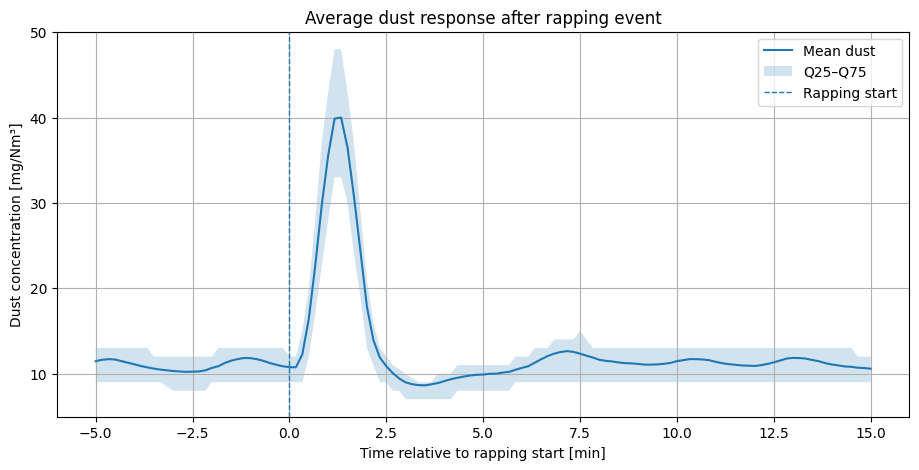

In [14]:
plt.figure(figsize=(11, 5))

x = avg_response.index
y = avg_response[TARGET_COL]

plt.plot(x, y, label="Mean dust")
plt.fill_between(
    x,
    q25_response[TARGET_COL],
    q75_response[TARGET_COL],
    alpha=0.2,
    label="Q25–Q75"
)

plt.axvline(0, linestyle="--", linewidth=1, label="Rapping start")
plt.xlabel("Time relative to rapping start [min]")
plt.ylabel("Dust concentration [mg/Nm³]")
plt.title("Average dust response after rapping event")
plt.legend()
plt.grid(True)
plt.show()

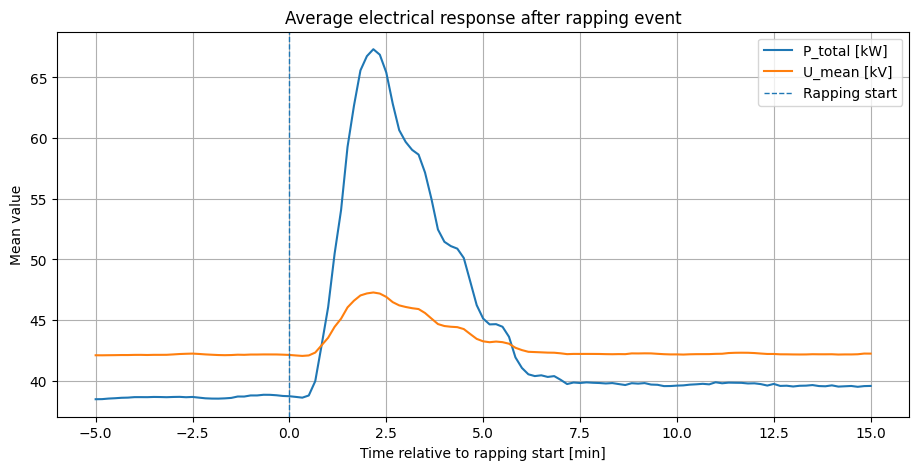

In [15]:
plt.figure(figsize=(11, 5))

plt.plot(avg_response.index, avg_response["P_total"], label="P_total [kW]")
plt.plot(avg_response.index, avg_response["U_mean"], label="U_mean [kV]")

plt.axvline(0, linestyle="--", linewidth=1, label="Rapping start")
plt.xlabel("Time relative to rapping start [min]")
plt.ylabel("Mean value")
plt.title("Average electrical response after rapping event")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
baseline_window = (-5, -1)

event_relative = []

for event_id, group in events_df.groupby("event_id"):
    baseline_mask = (
        (group["t_rel_min"] >= baseline_window[0])
        & (group["t_rel_min"] <= baseline_window[1])
    )
    
    if baseline_mask.sum() == 0:
        continue
    
    baseline = group.loc[baseline_mask, signals_for_event].mean()
    
    rel = group.copy()
    for col in signals_for_event:
        rel[col + "_rel"] = rel[col] - baseline[col]
    
    event_relative.append(rel)

events_rel_df = pd.concat(event_relative, axis=0)

rel_cols = [col + "_rel" for col in signals_for_event]

avg_rel_response = (
    events_rel_df
    .groupby("t_rel_min")[rel_cols]
    .mean()
)

q25_rel_response = (
    events_rel_df
    .groupby("t_rel_min")[rel_cols]
    .quantile(0.25)
)

q75_rel_response = (
    events_rel_df
    .groupby("t_rel_min")[rel_cols]
    .quantile(0.75)
)

avg_rel_response.head()

,008A01345_rel,P_total_rel,U_mean_rel,U_sum_rel,008A02289_rel,008A02290_rel,008A02291_rel,008A02267_rel,008A02268_rel,008A02269_rel,008A02273_rel,008A02274_rel,008A02275_rel
t_rel_min,,,,,,,,,,,,,
-5.000000,0.471962,-0.136520,-0.043026,-0.129078,-0.046241,-0.046241,-0.036596,-0.500142,-0.602553,-0.874421,-0.046459,-0.041400,-0.048662
-4.833333,0.637447,-0.128719,-0.046178,-0.138534,-0.050969,-0.050969,-0.036596,-0.367754,-0.690024,-0.834232,-0.037712,-0.043054,-0.047953
-4.666667,0.708369,-0.082147,-0.039086,-0.117258,-0.039149,-0.046241,-0.031868,0.008132,-0.446525,-0.628558,-0.015489,-0.030998,-0.035660
-4.500000,0.668180,-0.055196,-0.033570,-0.100709,-0.034421,-0.041513,-0.024775,-0.081702,-0.304681,-0.101371,-0.017853,-0.024142,-0.013201
-4.333333,0.476690,-0.018553,-0.024113,-0.072340,-0.029693,-0.020236,-0.022411,-0.039149,-0.013901,0.054657,-0.013362,-0.006175,0.000983


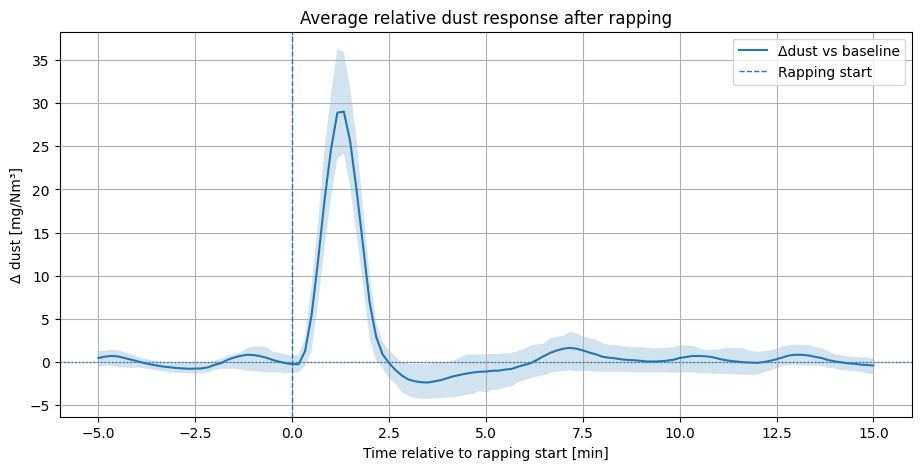

In [17]:
plt.figure(figsize=(11, 5))

x = avg_rel_response.index

plt.plot(x, avg_rel_response[TARGET_COL + "_rel"], label="Δdust vs baseline")
plt.fill_between(
    x,
    q25_rel_response[TARGET_COL + "_rel"],
    q75_rel_response[TARGET_COL + "_rel"],
    alpha=0.2
)

plt.axvline(0, linestyle="--", linewidth=1, label="Rapping start")
plt.axhline(0, linestyle=":", linewidth=1)
plt.xlabel("Time relative to rapping start [min]")
plt.ylabel("Δ dust [mg/Nm³]")
plt.title("Average relative dust response after rapping")
plt.legend()
plt.grid(True)
plt.show()

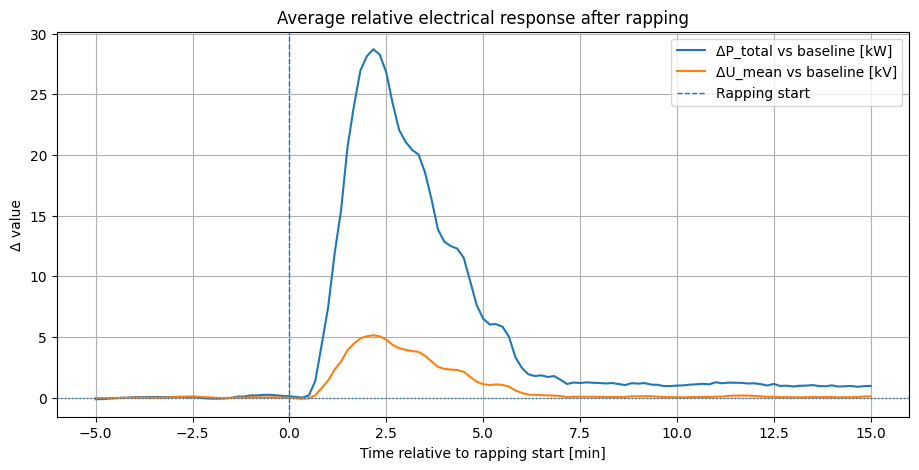

In [18]:
plt.figure(figsize=(11, 5))

plt.plot(x, avg_rel_response["P_total_rel"], label="ΔP_total vs baseline [kW]")
plt.plot(x, avg_rel_response["U_mean_rel"], label="ΔU_mean vs baseline [kV]")

plt.axvline(0, linestyle="--", linewidth=1, label="Rapping start")
plt.axhline(0, linestyle=":", linewidth=1)
plt.xlabel("Time relative to rapping start [min]")
plt.ylabel("Δ value")
plt.title("Average relative electrical response after rapping")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
event_metrics = []

for event_id, group in events_rel_df.groupby("event_id"):
    after_0_5 = group[(group["t_rel_min"] >= 0) & (group["t_rel_min"] <= 5)]
    after_0_15 = group[(group["t_rel_min"] >= 0) & (group["t_rel_min"] <= 15)]
    
    if len(after_0_5) == 0 or len(after_0_15) == 0:
        continue
    
    dust_rel_col = TARGET_COL + "_rel"
    P_rel_col = "P_total_rel"
    U_rel_col = "U_mean_rel"
    
    dust_peak_idx = after_0_5[dust_rel_col].idxmax()
    P_peak_idx = after_0_15[P_rel_col].idxmax()
    U_peak_idx = after_0_15[U_rel_col].idxmax()
    
    event_metrics.append({
        "event_id": event_id,
        "event_time": group["event_time"].iloc[0],
        "dust_peak_0_5min_rel": after_0_5.loc[dust_peak_idx, dust_rel_col],
        "time_to_dust_peak_min": after_0_5.loc[dust_peak_idx, "t_rel_min"],
        "P_peak_0_15min_rel": after_0_15.loc[P_peak_idx, P_rel_col],
        "time_to_P_peak_min": after_0_15.loc[P_peak_idx, "t_rel_min"],
        "U_peak_0_15min_rel": after_0_15.loc[U_peak_idx, U_rel_col],
        "time_to_U_peak_min": after_0_15.loc[U_peak_idx, "t_rel_min"],
    })

event_metrics = pd.DataFrame(event_metrics)

event_metrics.describe()

,event_id,event_time,dust_peak_0_5min_rel,time_to_dust_peak_min,P_peak_0_15min_rel,time_to_P_peak_min,U_peak_0_15min_rel,time_to_U_peak_min
count,423.000000,423,423.000000,423.000000,423.000000,423.000000,4.230000e+02,423.000000
mean,211.000000,2025-07-17 08:16:05.248226816,30.074799,1.165091,30.267026,2.623325,5.388022e+00,2.303388
min,0.000000,2025-06-30 00:51:00,0.000000,0.000000,-0.104001,0.000000,-7.105427e-15,0.000000
25%,105.500000,2025-07-09 00:04:55,25.180000,1.000000,27.698000,1.833333,4.833333e+00,1.666667
50%,211.000000,2025-07-17 09:29:00,31.200000,1.166667,29.056000,2.166667,5.800000e+00,1.833333
75%,316.500000,2025-07-25 21:39:55,36.560000,1.166667,37.499999,2.500000,6.666667e+00,2.166667
max,422.000000,2025-07-31 23:41:30,61.640000,4.833333,249.151997,15.000000,2.466667e+01,15.000000
std,122.253834,NaN,10.532221,0.486384,19.654056,2.039038,2.397785e+00,1.920935


In [20]:
summary_cols = [
    "dust_peak_0_5min_rel",
    "time_to_dust_peak_min",
    "P_peak_0_15min_rel",
    "time_to_P_peak_min",
    "U_peak_0_15min_rel",
    "time_to_U_peak_min",
]

event_metrics[summary_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,dust_peak_0_5min_rel,time_to_dust_peak_min,P_peak_0_15min_rel,time_to_P_peak_min,U_peak_0_15min_rel,time_to_U_peak_min
count,423.000000,423.000000,423.000000,423.000000,4.230000e+02,423.000000
mean,30.074799,1.165091,30.267026,2.623325,5.388022e+00,2.303388
std,10.532221,0.486384,19.654056,2.039038,2.397785e+00,1.920935
min,0.000000,0.000000,-0.104001,0.000000,-7.105427e-15,0.000000
25%,25.180000,1.000000,27.698000,1.833333,4.833333e+00,1.666667
50%,31.200000,1.166667,29.056000,2.166667,5.800000e+00,1.833333
75%,36.560000,1.166667,37.499999,2.500000,6.666667e+00,2.166667
90%,41.304000,1.333333,44.105601,3.000000,7.346667e+00,2.833333
95%,43.984000,1.333333,47.371602,5.833333,8.000000e+00,5.633333
max,61.640000,4.833333,249.151997,15.000000,2.466667e+01,15.000000


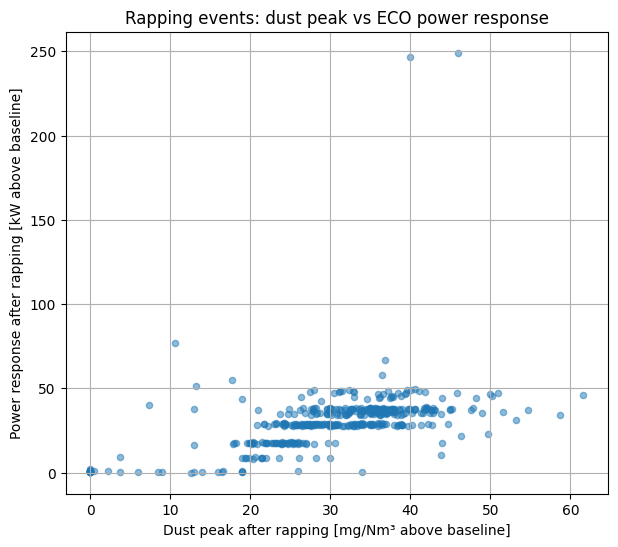

np.float64(0.503712895463243)

In [21]:
plt.figure(figsize=(7, 6))

plt.scatter(
    event_metrics["dust_peak_0_5min_rel"],
    event_metrics["P_peak_0_15min_rel"],
    alpha=0.5,
    s=20
)

plt.xlabel("Dust peak after rapping [mg/Nm³ above baseline]")
plt.ylabel("Power response after rapping [kW above baseline]")
plt.title("Rapping events: dust peak vs ECO power response")
plt.grid(True)
plt.show()

corr_peak_response = event_metrics["dust_peak_0_5min_rel"].corr(
    event_metrics["P_peak_0_15min_rel"]
)

corr_peak_response

In [22]:
corr_peak_response = event_metrics["dust_peak_0_5min_rel"].corr(
    event_metrics["P_peak_0_15min_rel"]
)

corr_peak_response

np.float64(0.503712895463243)

In [23]:
event_metrics.sort_values("P_peak_0_15min_rel", ascending=False).head(15)

,event_id,event_time,dust_peak_0_5min_rel,time_to_dust_peak_min,P_peak_0_15min_rel,time_to_P_peak_min,U_peak_0_15min_rel,time_to_U_peak_min
50,50,2025-07-03 17:25:00,46.00,1.166667,249.151997,6.833333,24.666667,5.666667
346,346,2025-07-27 14:28:50,40.00,1.333333,246.415997,11.000000,21.120000,12.500000
290,290,2025-07-24 08:59:10,10.60,1.166667,76.727999,7.666667,11.400000,7.666667
223,223,2025-07-20 12:13:10,36.80,1.000000,66.600000,15.000000,9.000000,15.000000
140,140,2025-07-10 23:50:40,36.40,1.000000,57.860001,1.833333,10.040000,1.833333
224,224,2025-07-20 13:38:10,17.76,1.166667,54.648000,2.166667,7.906667,1.666667
15,15,2025-06-30 21:36:10,13.16,1.166667,51.356001,1.500000,7.813333,1.500000
204,204,2025-07-16 23:48:00,40.64,1.000000,49.400002,2.833333,9.280000,2.833333
329,329,2025-07-26 14:58:20,40.04,1.000000,48.996001,2.333333,8.626667,1.833333
196,196,2025-07-16 12:43:50,27.92,1.166667,48.888000,2.833333,8.666667,2.833333


In [24]:
typical_events = event_metrics[
    (event_metrics["P_peak_0_15min_rel"] >= 0)
    & (event_metrics["P_peak_0_15min_rel"] < event_metrics["P_peak_0_15min_rel"].quantile(0.98))
].copy()

print("All events:", len(event_metrics))
print("Typical events:", len(typical_events))
print("Removed:", len(event_metrics) - len(typical_events))

typical_events[summary_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

All events: 423
Typical events: 413
Removed: 10


,dust_peak_0_5min_rel,time_to_dust_peak_min,P_peak_0_15min_rel,time_to_P_peak_min,U_peak_0_15min_rel,time_to_U_peak_min
count,413.000000,413.000000,413.000000,413.000000,4.130000e+02,413.000000
mean,30.091138,1.157789,28.818160,2.535513,5.251590e+00,2.229217
std,10.455719,0.460613,12.127406,1.847825,2.010619e+00,1.739835
min,0.000000,0.000000,0.040000,0.000000,-7.105427e-15,0.000000
25%,25.280000,1.000000,27.644000,1.833333,4.693333e+00,1.666667
50%,31.200000,1.166667,28.972000,2.166667,5.720000e+00,1.833333
75%,36.440000,1.166667,37.355999,2.500000,6.626667e+00,2.166667
90%,41.304000,1.333333,38.517599,2.966667,7.032000e+00,2.800000
95%,43.904000,1.333333,46.224801,5.566667,7.805333e+00,5.333333
max,61.640000,4.833333,48.888000,14.833333,8.853333e+00,14.833333


In [25]:
corr_peak_response_typical = typical_events["dust_peak_0_5min_rel"].corr(
    typical_events["P_peak_0_15min_rel"]
)

corr_peak_response_typical

np.float64(0.7389389742910993)

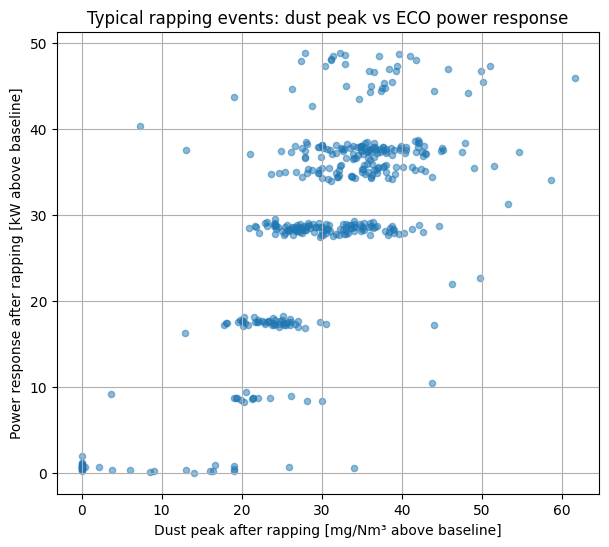

In [26]:
plt.figure(figsize=(7, 6))

plt.scatter(
    typical_events["dust_peak_0_5min_rel"],
    typical_events["P_peak_0_15min_rel"],
    alpha=0.5,
    s=20
)

plt.xlabel("Dust peak after rapping [mg/Nm³ above baseline]")
plt.ylabel("Power response after rapping [kW above baseline]")
plt.title("Typical rapping events: dust peak vs ECO power response")
plt.grid(True)
plt.show()

In [27]:
POWER_RESPONSE_THRESHOLD_KW = 5.0
DUST_RESPONSE_THRESHOLD_MG = 5.0

duration_metrics = []

for event_id, group in events_rel_df.groupby("event_id"):
    after = group[(group["t_rel_min"] >= 0) & (group["t_rel_min"] <= 15)].copy()
    
    if len(after) == 0:
        continue
    
    p_rel = after["P_total_rel"]
    dust_rel = after[TARGET_COL + "_rel"]
    
    # czas próbkowania w godzinach: 10 s = 10/3600 h
    sample_hours = 10 / 3600
    
    # dodatkowa energia tylko tam, gdzie P_rel > 0
    extra_energy_kwh = p_rel.clip(lower=0).sum() * sample_hours
    
    power_above = p_rel > POWER_RESPONSE_THRESHOLD_KW
    dust_above = dust_rel > DUST_RESPONSE_THRESHOLD_MG
    
    power_duration_min = power_above.sum() / samples_per_min
    dust_duration_min = dust_above.sum() / samples_per_min
    
    duration_metrics.append({
        "event_id": event_id,
        "event_time": group["event_time"].iloc[0],
        "extra_energy_kwh_0_15min": extra_energy_kwh,
        "power_duration_above_5kw_min": power_duration_min,
        "dust_duration_above_5mg_min": dust_duration_min,
        "power_minus_dust_duration_min": power_duration_min - dust_duration_min,
    })

duration_metrics = pd.DataFrame(duration_metrics)

duration_metrics.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,event_id,event_time,extra_energy_kwh_0_15min,power_duration_above_5kw_min,dust_duration_above_5mg_min,power_minus_dust_duration_min
count,423.000000,423,423.000000,423.000000,423.000000,423.000000
mean,211.000000,2025-07-17 08:16:05.248226816,1.574750,4.051221,2.152876,1.898345
min,0.000000,2025-06-30 00:51:00,0.000000,0.000000,0.000000,-9.333333
25%,105.500000,2025-07-09 00:04:55,0.997372,3.500000,1.500000,0.666667
50%,211.000000,2025-07-17 09:29:00,1.141944,3.833333,1.666667,2.000000
75%,316.500000,2025-07-25 21:39:55,1.823861,5.000000,2.666667,3.333333
90%,379.800000,2025-07-29 13:17:10,2.702311,6.333333,3.633333,4.133333
95%,400.900000,2025-07-30 18:29:03,2.839347,6.500000,4.000000,4.833333
max,422.000000,2025-07-31 23:41:30,42.402978,14.666667,13.000000,12.500000
std,122.253834,NaN,2.858639,2.058134,1.281324,2.111751


In [29]:
event_analysis = event_metrics.merge(
    duration_metrics,
    on=["event_id", "event_time"],
    how="left"
)

event_analysis.head()

,event_id,event_time,dust_peak_0_5min_rel,time_to_dust_peak_min,P_peak_0_15min_rel,time_to_P_peak_min,U_peak_0_15min_rel,time_to_U_peak_min,extra_energy_kwh_0_15min,power_duration_above_5kw_min,dust_duration_above_5mg_min,power_minus_dust_duration_min
0,0,2025-06-30 00:51:00,25.80,1.333333,28.252001,1.500000,5.960000,1.500000,1.088178,3.833333,2.500000,1.333333
1,1,2025-06-30 02:13:50,29.64,1.000000,35.215999,1.666667,6.346667,1.666667,1.771767,5.000000,2.000000,3.000000
2,2,2025-06-30 03:36:30,26.40,1.333333,27.736001,1.833333,4.946667,1.666667,1.000256,3.666667,1.666667,2.000000
3,3,2025-06-30 04:59:20,30.00,1.000000,28.108001,1.333333,5.240000,1.333333,1.066633,3.666667,3.000000,0.666667
4,4,2025-06-30 06:22:00,23.88,1.166667,17.444001,2.000000,3.333333,1.666667,0.499656,2.166667,1.500000,0.666667


In [30]:
event_analysis[
    [
        "dust_peak_0_5min_rel",
        "P_peak_0_15min_rel",
        "U_peak_0_15min_rel",
        "time_to_dust_peak_min",
        "time_to_P_peak_min",
        "extra_energy_kwh_0_15min",
        "power_duration_above_5kw_min",
        "dust_duration_above_5mg_min",
        "power_minus_dust_duration_min",
    ]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,dust_peak_0_5min_rel,P_peak_0_15min_rel,U_peak_0_15min_rel,time_to_dust_peak_min,time_to_P_peak_min,extra_energy_kwh_0_15min,power_duration_above_5kw_min,dust_duration_above_5mg_min,power_minus_dust_duration_min
count,423.000000,423.000000,4.230000e+02,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000
mean,30.074799,30.267026,5.388022e+00,1.165091,2.623325,1.574750,4.051221,2.152876,1.898345
std,10.532221,19.654056,2.397785e+00,0.486384,2.039038,2.858639,2.058134,1.281324,2.111751
min,0.000000,-0.104001,-7.105427e-15,0.000000,0.000000,0.000000,0.000000,0.000000,-9.333333
25%,25.180000,27.698000,4.833333e+00,1.000000,1.833333,0.997372,3.500000,1.500000,0.666667
50%,31.200000,29.056000,5.800000e+00,1.166667,2.166667,1.141944,3.833333,1.666667,2.000000
75%,36.560000,37.499999,6.666667e+00,1.166667,2.500000,1.823861,5.000000,2.666667,3.333333
90%,41.304000,44.105601,7.346667e+00,1.333333,3.000000,2.702311,6.333333,3.633333,4.133333
95%,43.984000,47.371602,8.000000e+00,1.333333,5.833333,2.839347,6.500000,4.000000,4.833333
max,61.640000,249.151997,2.466667e+01,4.833333,15.000000,42.402978,14.666667,13.000000,12.500000


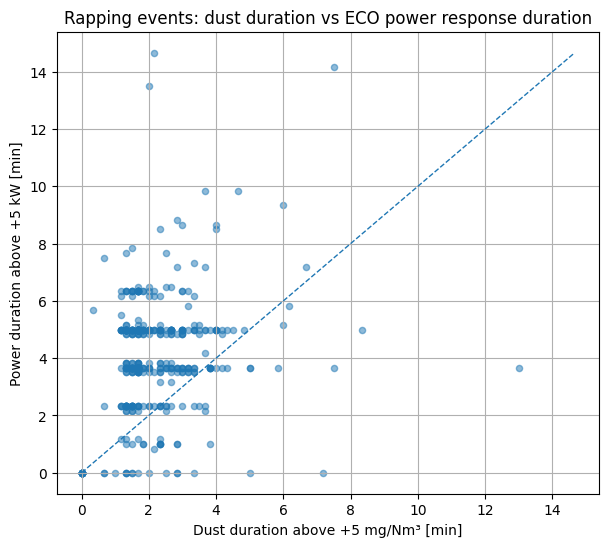

In [31]:
plt.figure(figsize=(7, 6))

plt.scatter(
    event_analysis["dust_duration_above_5mg_min"],
    event_analysis["power_duration_above_5kw_min"],
    alpha=0.5,
    s=20
)

max_val = max(
    event_analysis["dust_duration_above_5mg_min"].max(),
    event_analysis["power_duration_above_5kw_min"].max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)

plt.xlabel("Dust duration above +5 mg/Nm³ [min]")
plt.ylabel("Power duration above +5 kW [min]")
plt.title("Rapping events: dust duration vs ECO power response duration")
plt.grid(True)
plt.show()

In [32]:
candidate_overreaction = event_analysis[
    (event_analysis["dust_peak_0_5min_rel"] < event_analysis["dust_peak_0_5min_rel"].quantile(0.75))
    & (event_analysis["power_duration_above_5kw_min"] > event_analysis["power_duration_above_5kw_min"].quantile(0.75))
    & (event_analysis["extra_energy_kwh_0_15min"] > event_analysis["extra_energy_kwh_0_15min"].quantile(0.75))
].copy()

candidate_overreaction = candidate_overreaction.sort_values(
    "extra_energy_kwh_0_15min",
    ascending=False
)

print("Candidate overreaction events:", len(candidate_overreaction))
candidate_overreaction.head(20)

Candidate overreaction events: 30


,event_id,event_time,dust_peak_0_5min_rel,time_to_dust_peak_min,P_peak_0_15min_rel,time_to_P_peak_min,U_peak_0_15min_rel,time_to_U_peak_min,extra_energy_kwh_0_15min,power_duration_above_5kw_min,dust_duration_above_5mg_min,power_minus_dust_duration_min
290,290,2025-07-24 08:59:10,10.60,1.166667,76.727999,7.666667,11.400000,7.666667,10.897633,14.666667,2.166667,12.500000
15,15,2025-06-30 21:36:10,13.16,1.166667,51.356001,1.500000,7.813333,1.500000,3.877789,7.500000,0.666667,6.833333
224,224,2025-07-20 13:38:10,17.76,1.166667,54.648000,2.166667,7.906667,1.666667,3.870856,7.666667,1.333333,6.333333
140,140,2025-07-10 23:50:40,36.40,1.000000,57.860001,1.833333,10.040000,1.833333,3.860056,7.833333,1.500000,6.333333
288,288,2025-07-24 06:11:30,32.28,1.000000,48.828000,2.166667,8.333333,2.000000,2.911767,6.333333,1.666667,4.666667
356,356,2025-07-28 04:20:20,31.12,1.333333,48.072000,3.000000,8.320000,2.166667,2.886189,6.333333,2.000000,4.333333
339,339,2025-07-27 04:47:20,32.88,1.166667,48.652000,2.833333,8.666667,2.333333,2.852644,6.166667,1.166667,5.000000
154,154,2025-07-11 19:13:00,35.24,1.166667,35.863999,1.833333,6.666667,2.000000,2.844167,8.666667,4.000000,4.666667
272,272,2025-07-23 08:03:30,27.40,1.333333,47.928001,3.000000,8.000000,2.000000,2.829567,6.166667,2.333333,3.833333
276,276,2025-07-23 13:36:50,32.92,1.166667,47.551999,2.333333,8.000000,2.166667,2.817022,6.333333,2.166667,4.166667


In [33]:
def plot_rapping_event(event_id):
    group = events_rel_df[events_rel_df["event_id"] == event_id].copy()
    
    if group.empty:
        print("No event:", event_id)
        return
    
    event_time = group["event_time"].iloc[0]
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    
    ax1.plot(
        group["t_rel_min"],
        group[TARGET_COL + "_rel"],
        label="Δdust [mg/Nm³]",
    )
    ax1.set_xlabel("Time relative to rapping start [min]")
    ax1.set_ylabel("Δdust [mg/Nm³]")
    ax1.axvline(0, linestyle="--", linewidth=1)
    ax1.axhline(0, linestyle=":", linewidth=1)
    
    ax2 = ax1.twinx()
    ax2.plot(
        group["t_rel_min"],
        group["P_total_rel"],
        label="ΔP_total [kW]",
        linestyle="--",
    )
    ax2.plot(
        group["t_rel_min"],
        group["U_mean_rel"],
        label="ΔU_mean [kV]",
        linestyle=":",
    )
    ax2.set_ylabel("ΔP [kW] / ΔU [kV]")
    
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")
    
    plt.title(f"Rapping event {event_id} at {event_time}")
    plt.grid(True)
    plt.show()

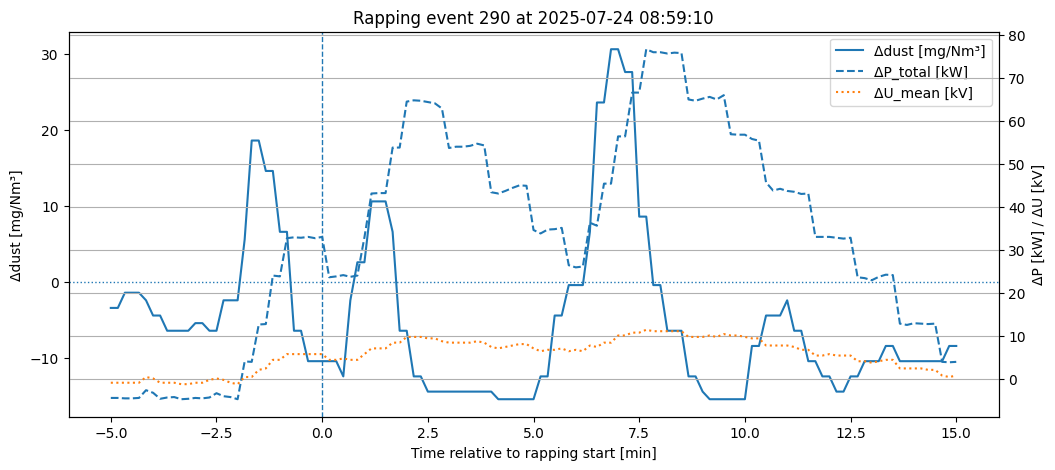

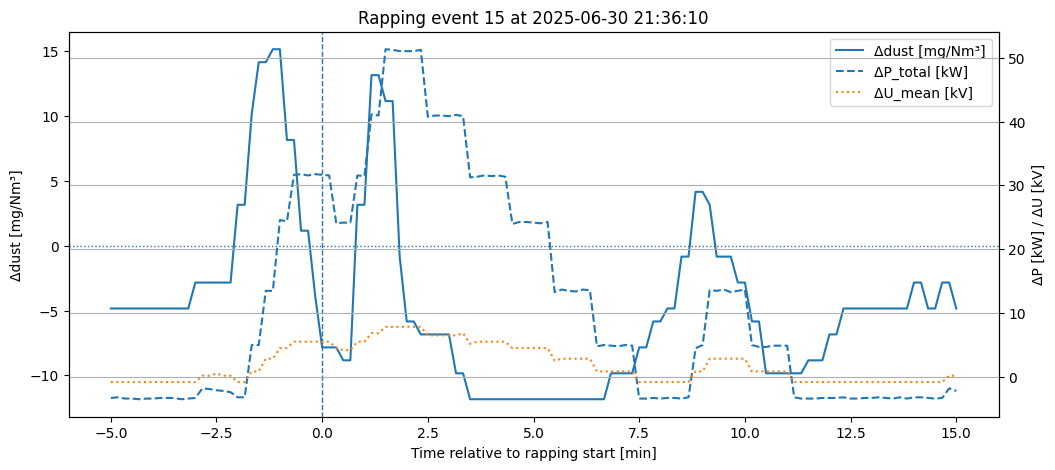

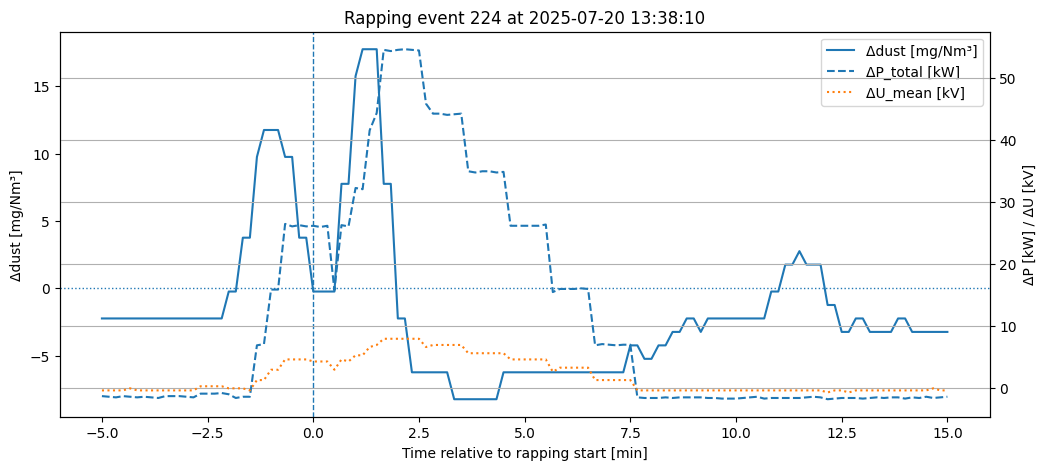

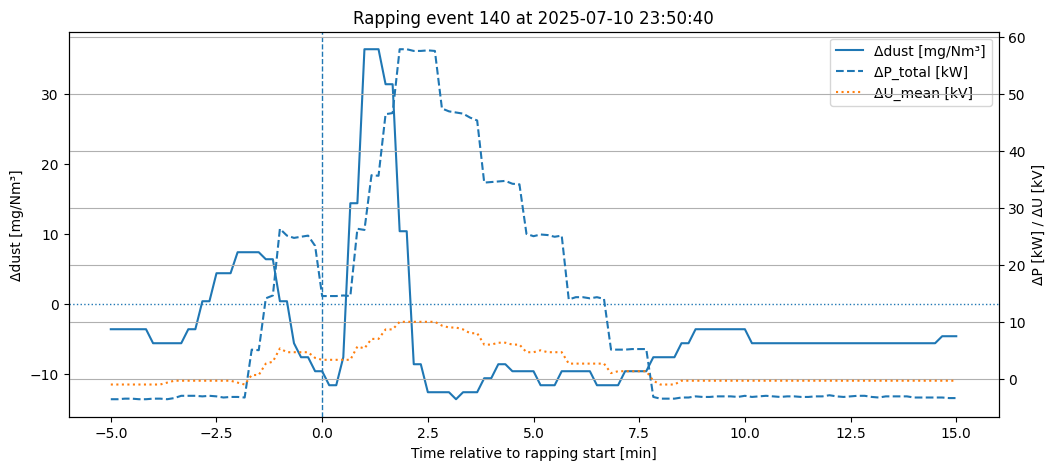

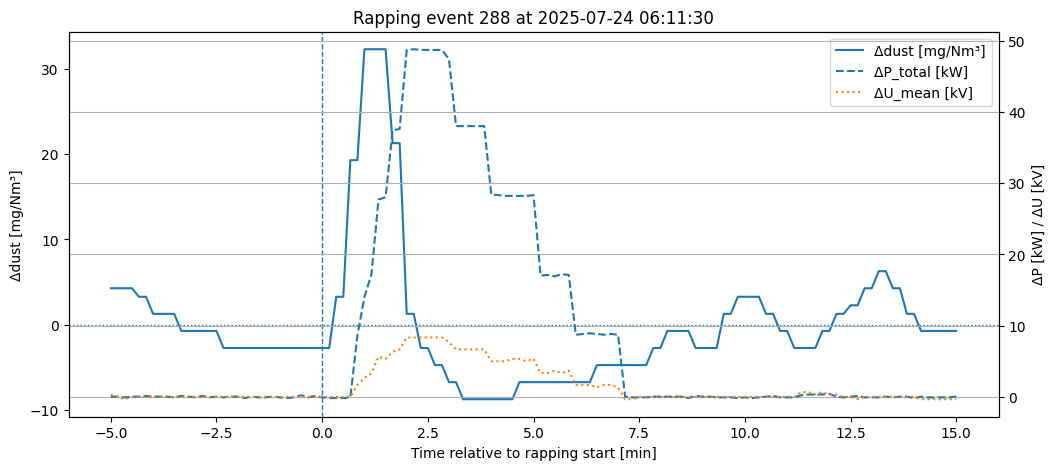

In [34]:
for eid in candidate_overreaction["event_id"].head(5):
    plot_rapping_event(eid)

In [35]:
# Filtr diagnostyczny: usuwamy najbardziej ekstremalne 2% reakcji energetycznych
energy_upper = event_analysis["extra_energy_kwh_0_15min"].quantile(0.98)
power_upper = event_analysis["P_peak_0_15min_rel"].quantile(0.98)

typical_event_analysis = event_analysis[
    (event_analysis["extra_energy_kwh_0_15min"] <= energy_upper)
    & (event_analysis["P_peak_0_15min_rel"] <= power_upper)
].copy()

print("All events:", len(event_analysis))
print("Typical events:", len(typical_event_analysis))
print("Removed events:", len(event_analysis) - len(typical_event_analysis))

typical_event_analysis[
    [
        "dust_peak_0_5min_rel",
        "P_peak_0_15min_rel",
        "U_peak_0_15min_rel",
        "time_to_dust_peak_min",
        "time_to_P_peak_min",
        "extra_energy_kwh_0_15min",
        "power_duration_above_5kw_min",
        "dust_duration_above_5mg_min",
        "power_minus_dust_duration_min",
    ]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

All events: 423
Typical events: 412
Removed events: 11


,dust_peak_0_5min_rel,P_peak_0_15min_rel,U_peak_0_15min_rel,time_to_dust_peak_min,time_to_P_peak_min,extra_energy_kwh_0_15min,power_duration_above_5kw_min,dust_duration_above_5mg_min,power_minus_dust_duration_min
count,412.000000,412.000000,4.120000e+02,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000
mean,29.999417,28.655136,5.224595e+00,1.166667,2.551780,1.322985,3.905340,2.127832,1.777508
std,10.479472,12.151516,2.015205e+00,0.492441,1.895596,0.779141,1.815219,1.248401,1.945176
min,0.000000,-0.104001,-7.105427e-15,0.000000,0.000000,0.000000,0.000000,0.000000,-9.333333
25%,25.190000,27.496999,4.596667e+00,1.000000,1.833333,0.985483,3.500000,1.500000,0.666667
50%,31.080000,28.940001,5.700000e+00,1.166667,2.166667,1.106578,3.833333,1.666667,2.000000
75%,36.400000,37.331001,6.603333e+00,1.166667,2.500000,1.817875,5.000000,2.666667,3.333333
90%,41.280000,38.428401,7.000000e+00,1.333333,2.983333,2.245533,6.133333,3.500000,3.833333
95%,43.912000,45.531602,7.690667e+00,1.333333,5.666667,2.772737,6.333333,4.000000,4.666667
max,61.640000,48.888000,8.680000e+00,4.833333,14.833333,3.690244,9.833333,13.000000,6.166667


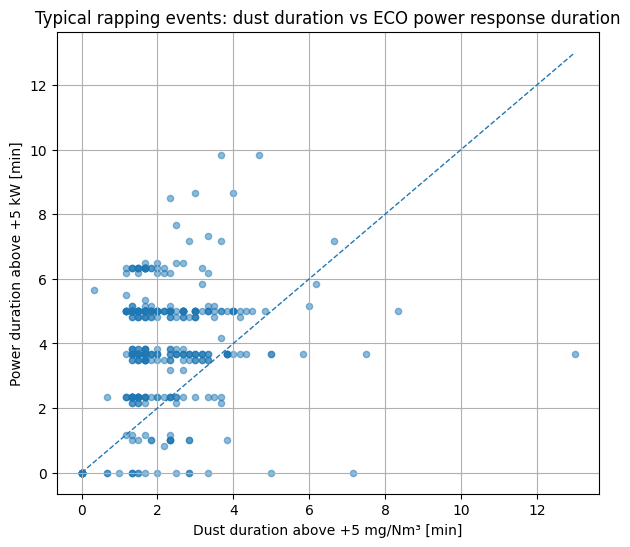

In [36]:
plt.figure(figsize=(7, 6))

plt.scatter(
    typical_event_analysis["dust_duration_above_5mg_min"],
    typical_event_analysis["power_duration_above_5kw_min"],
    alpha=0.5,
    s=20
)

max_val = max(
    typical_event_analysis["dust_duration_above_5mg_min"].max(),
    typical_event_analysis["power_duration_above_5kw_min"].max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)

plt.xlabel("Dust duration above +5 mg/Nm³ [min]")
plt.ylabel("Power duration above +5 kW [min]")
plt.title("Typical rapping events: dust duration vs ECO power response duration")
plt.grid(True)
plt.show()

In [37]:
fraction_power_longer = (
    typical_event_analysis["power_duration_above_5kw_min"]
    > typical_event_analysis["dust_duration_above_5mg_min"]
).mean()

fraction_power_longer

np.float64(0.8106796116504854)

In [38]:
TAIL_POWER_THRESHOLD_KW = 5.0
TAIL_DUST_THRESHOLD_MG = 5.0

tail_energy_rows = []

for event_id, group in events_rel_df.groupby("event_id"):
    after = group[(group["t_rel_min"] >= 0) & (group["t_rel_min"] <= 15)].copy()
    
    if len(after) == 0:
        continue
    
    p_rel = after["P_total_rel"]
    dust_rel = after[TARGET_COL + "_rel"]
    
    sample_hours = 10 / 3600
    
    # energia "ogonowa": moc podwyższona, ale pył już nie jest podwyższony
    tail_mask = (p_rel > TAIL_POWER_THRESHOLD_KW) & (dust_rel <= TAIL_DUST_THRESHOLD_MG)
    
    tail_energy_kwh = p_rel.where(tail_mask, 0).clip(lower=0).sum() * sample_hours
    tail_duration_min = tail_mask.sum() / samples_per_min
    
    tail_energy_rows.append({
        "event_id": event_id,
        "tail_energy_kwh_0_15min": tail_energy_kwh,
        "tail_duration_min": tail_duration_min,
    })

tail_energy = pd.DataFrame(tail_energy_rows)

event_analysis = event_analysis.merge(
    tail_energy,
    on="event_id",
    how="left"
)

typical_event_analysis = typical_event_analysis.merge(
    tail_energy,
    on="event_id",
    how="left"
)

typical_event_analysis[
    [
        "extra_energy_kwh_0_15min",
        "tail_energy_kwh_0_15min",
        "tail_duration_min",
    ]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,extra_energy_kwh_0_15min,tail_energy_kwh_0_15min,tail_duration_min
count,412.000000,412.000000,412.000000
mean,1.322985,0.930476,2.785194
std,0.779141,0.642136,1.460590
min,0.000000,0.000000,0.000000
25%,0.985483,0.500886,2.000000
50%,1.106578,0.754200,2.666667
75%,1.817875,1.345933,3.708333
90%,2.245533,1.566762,4.666667
95%,2.772737,2.210100,5.000000
max,3.690244,2.550622,7.000000


In [39]:
typical_event_analysis["tail_energy_share"] = (
    typical_event_analysis["tail_energy_kwh_0_15min"]
    / typical_event_analysis["extra_energy_kwh_0_15min"].replace(0, np.nan)
)

typical_event_analysis[
    ["tail_energy_share"]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,tail_energy_share
count,411.000000
mean,0.603319
std,0.225524
min,0.000000
25%,0.568523
50%,0.667192
75%,0.744514
90%,0.780623
95%,0.831655
max,0.906100


In [40]:
candidate_tail_saving = typical_event_analysis[
    (typical_event_analysis["tail_energy_share"] > typical_event_analysis["tail_energy_share"].quantile(0.75))
    & (typical_event_analysis["tail_duration_min"] > typical_event_analysis["tail_duration_min"].quantile(0.75))
    & (typical_event_analysis["dust_peak_0_5min_rel"] < typical_event_analysis["dust_peak_0_5min_rel"].quantile(0.75))
].copy()

candidate_tail_saving = candidate_tail_saving.sort_values(
    "tail_energy_kwh_0_15min",
    ascending=False
)

print("Candidate tail-saving events:", len(candidate_tail_saving))

candidate_tail_saving[
    [
        "event_id",
        "event_time",
        "dust_peak_0_5min_rel",
        "P_peak_0_15min_rel",
        "extra_energy_kwh_0_15min",
        "tail_energy_kwh_0_15min",
        "tail_energy_share",
        "tail_duration_min",
        "power_duration_above_5kw_min",
        "dust_duration_above_5mg_min",
    ]
].head(20)

Candidate tail-saving events: 57


,event_id,event_time,dust_peak_0_5min_rel,P_peak_0_15min_rel,extra_energy_kwh_0_15min,tail_energy_kwh_0_15min,tail_energy_share,tail_duration_min,power_duration_above_5kw_min,dust_duration_above_5mg_min
346,356,2025-07-28 04:20:20,31.12,48.072000,2.886189,2.459533,0.852173,5.166667,6.333333,2.000000
330,339,2025-07-27 04:47:20,32.88,48.652000,2.852644,2.441000,0.855697,5.000000,6.166667,1.166667
282,288,2025-07-24 06:11:30,32.28,48.828000,2.911767,2.430744,0.834801,5.166667,6.333333,1.666667
266,272,2025-07-23 08:03:30,27.40,47.928001,2.829567,2.412611,0.852643,5.000000,6.166667,2.333333
225,231,2025-07-20 23:17:20,30.48,47.376002,2.775344,2.331333,0.840016,5.000000,6.333333,1.333333
192,195,2025-07-16 11:19:20,31.40,48.512001,2.793922,2.314611,0.828445,5.000000,6.333333,1.333333
163,166,2025-07-12 11:50:00,31.20,48.188001,2.702378,2.291222,0.847854,5.000000,6.166667,2.166667
140,143,2025-07-11 03:58:50,33.00,44.995999,2.751011,2.244111,0.815740,5.000000,6.333333,1.500000
66,68,2025-07-06 20:10:50,26.32,44.720001,2.718278,2.214500,0.814670,5.166667,6.500000,2.666667
72,74,2025-07-07 04:29:30,36.08,44.344002,2.693722,2.195611,0.815084,5.000000,6.333333,1.333333


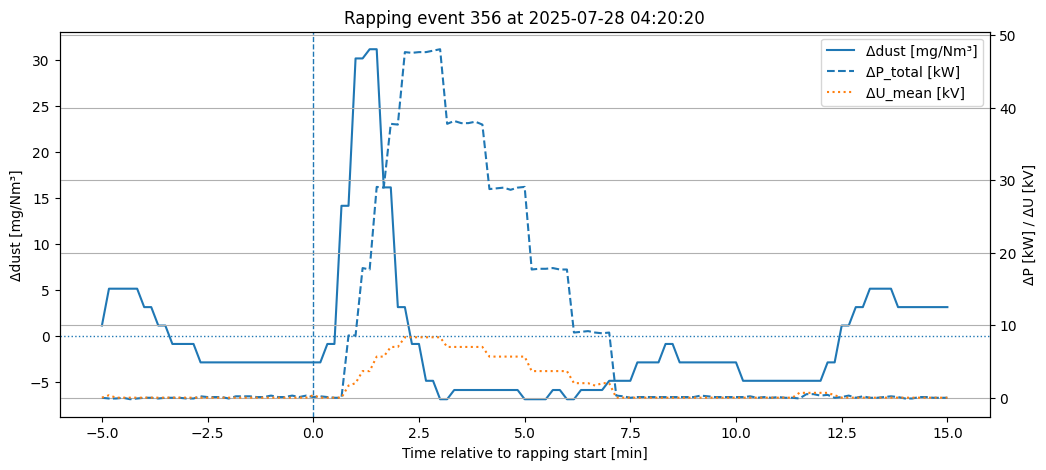

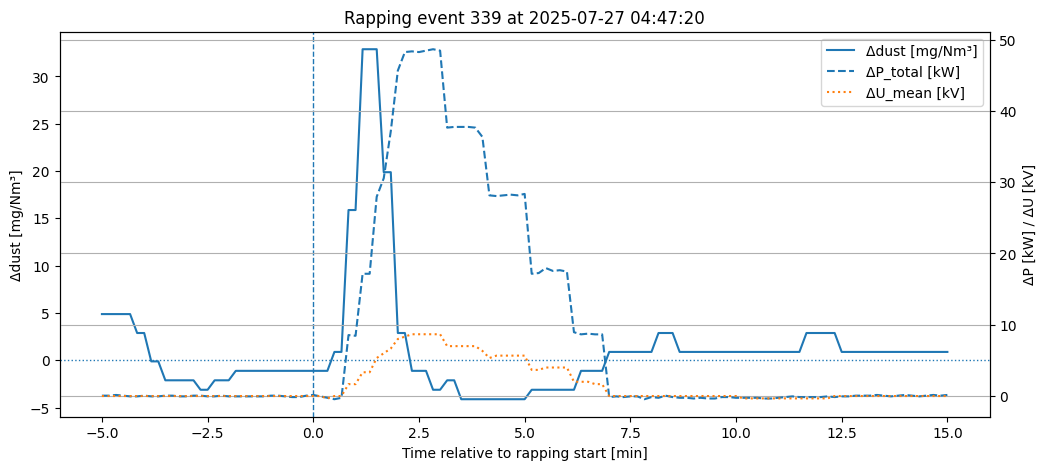

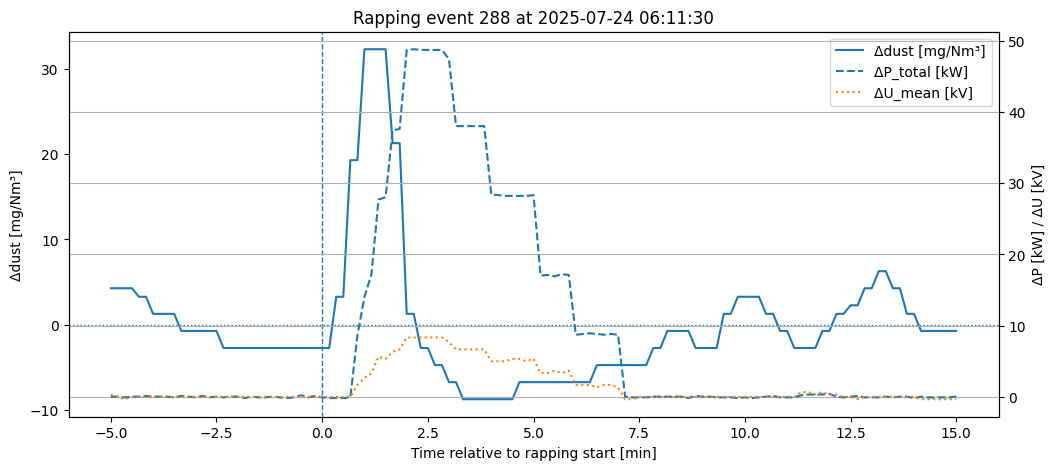

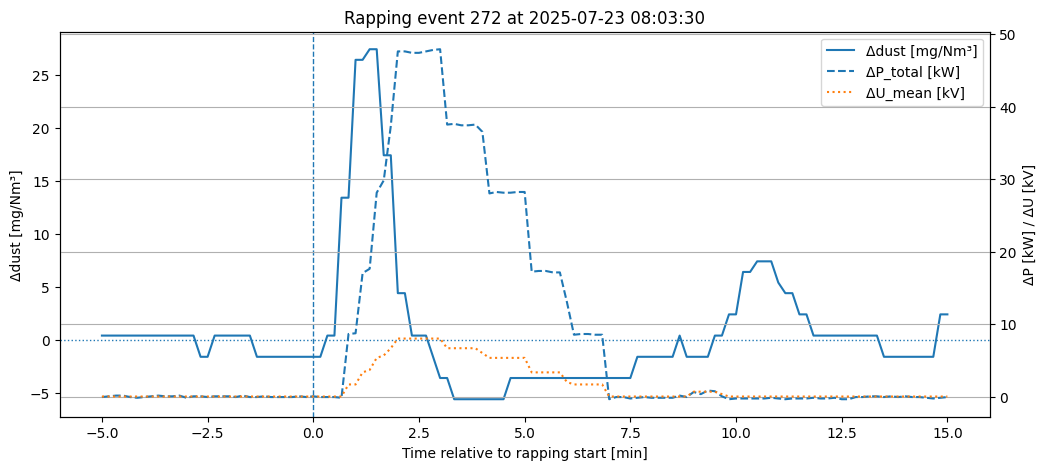

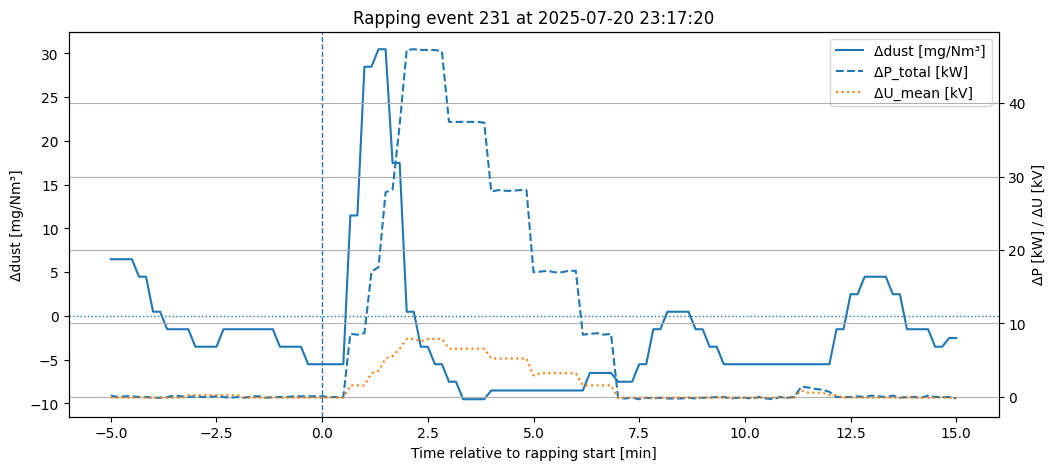

In [41]:
for eid in candidate_tail_saving["event_id"].head(5):
    plot_rapping_event(eid)

In [42]:
key_summary = {
    "n_events_all": len(event_analysis),
    "n_events_typical": len(typical_event_analysis),
    
    "median_dust_peak_mg": typical_event_analysis["dust_peak_0_5min_rel"].median(),
    "median_power_peak_kw": typical_event_analysis["P_peak_0_15min_rel"].median(),
    "median_u_peak_kv": typical_event_analysis["U_peak_0_15min_rel"].median(),
    
    "median_time_to_dust_peak_min": typical_event_analysis["time_to_dust_peak_min"].median(),
    "median_time_to_power_peak_min": typical_event_analysis["time_to_P_peak_min"].median(),
    
    "median_extra_energy_kwh": typical_event_analysis["extra_energy_kwh_0_15min"].median(),
    "median_tail_energy_kwh": typical_event_analysis["tail_energy_kwh_0_15min"].median(),
    "median_tail_energy_share": typical_event_analysis["tail_energy_share"].median(),
    
    "median_power_duration_min": typical_event_analysis["power_duration_above_5kw_min"].median(),
    "median_dust_duration_min": typical_event_analysis["dust_duration_above_5mg_min"].median(),
    "median_power_minus_dust_duration_min": typical_event_analysis["power_minus_dust_duration_min"].median(),
    
    "fraction_power_longer_than_dust": (
        typical_event_analysis["power_duration_above_5kw_min"]
        > typical_event_analysis["dust_duration_above_5mg_min"]
    ).mean(),
    
    "n_candidate_tail_saving": len(candidate_tail_saving),
}

key_summary = pd.Series(key_summary)
key_summary

n_events_all                            423.000000
n_events_typical                        412.000000
median_dust_peak_mg                      31.080000
median_power_peak_kw                     28.940001
median_u_peak_kv                          5.700000
median_time_to_dust_peak_min              1.166667
median_time_to_power_peak_min             2.166667
median_extra_energy_kwh                   1.106578
median_tail_energy_kwh                    0.754200
median_tail_energy_share                  0.667192
median_power_duration_min                 3.833333
median_dust_duration_min                  1.666667
median_power_minus_dust_duration_min      2.000000
fraction_power_longer_than_dust           0.810680
n_candidate_tail_saving                  57.000000
dtype: float64

### Kluczowy wynik: odpowiedź ECO po strzepywaniu zawiera mierzalną energię ogonową

Analiza typowych zdarzeń strzepywania pokazuje wyraźne przesunięcie czasowe pomiędzy pikiem stężenia pyłu a odpowiedzią elektryczną ESP. Mediana czasu wystąpienia piku pyłu wynosi około 1,17 min po rozpoczęciu strzepywania, natomiast mediana czasu maksymalnej odpowiedzi mocy występuje później, około 2,17 min po rozpoczęciu strzepywania. Potwierdza to, że odpowiedź elektryczna jest opóźniona względem piku pyłu, co jest zgodne z reaktywnym działaniem pętli ECO.

Dla typowych zdarzeń mediana piku pyłu wynosi około 31,1 mg/Nm³ powyżej poziomu bazowego, a mediana maksymalnej odpowiedzi mocy około 28,9 kW powyżej poziomu bazowego. Mediana czasu utrzymywania mocy powyżej progu +5 kW wynosi 3,83 min, podczas gdy mediana czasu utrzymywania pyłu powyżej progu +5 mg/Nm³ wynosi jedynie 1,67 min. W 81,1% typowych zdarzeń strzepywania odpowiedź mocy trwa dłużej niż podwyższone stężenie pyłu.

Mediana dodatkowej energii zużytej w oknie 0–15 min po strzepywaniu wynosi około 1,11 kWh na zdarzenie. Z tego mediana energii ogonowej wynosi około 0,75 kWh, co odpowiada około 66,7% dodatkowej energii. Energia ogonowa oznacza tę część odpowiedzi elektrycznej, w której moc ESP pozostaje podwyższona, mimo że stężenie pyłu wróciło już w pobliże poziomu bazowego. Nie należy interpretować jej jako energii bezpośrednio możliwej do usunięcia, ale jako wskaźnik górnego ograniczenia potencjalnej oszczędności w fazie powrotu po strzepywaniu.

In [43]:
# Alias dla względnych mocy sekcji
P1_REL = P_COLS["P1"] + "_rel"
P2_REL = P_COLS["P2"] + "_rel"
P3_REL = P_COLS["P3"] + "_rel"

U1_REL = U_COLS["U1"] + "_rel"
U2_REL = U_COLS["U2"] + "_rel"
U3_REL = U_COLS["U3"] + "_rel"

print(P1_REL, P2_REL, P3_REL)
print(U1_REL, U2_REL, U3_REL)

008A02273_rel 008A02274_rel 008A02275_rel
008A02289_rel 008A02290_rel 008A02291_rel


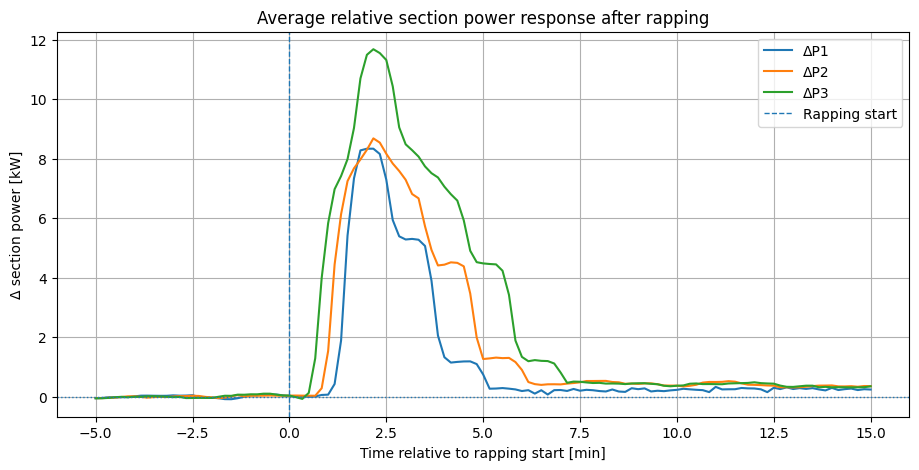

In [44]:
plt.figure(figsize=(11, 5))

plt.plot(avg_rel_response.index, avg_rel_response[P1_REL], label="ΔP1")
plt.plot(avg_rel_response.index, avg_rel_response[P2_REL], label="ΔP2")
plt.plot(avg_rel_response.index, avg_rel_response[P3_REL], label="ΔP3")

plt.axvline(0, linestyle="--", linewidth=1, label="Rapping start")
plt.axhline(0, linestyle=":", linewidth=1)

plt.xlabel("Time relative to rapping start [min]")
plt.ylabel("Δ section power [kW]")
plt.title("Average relative section power response after rapping")
plt.legend()
plt.grid(True)
plt.show()

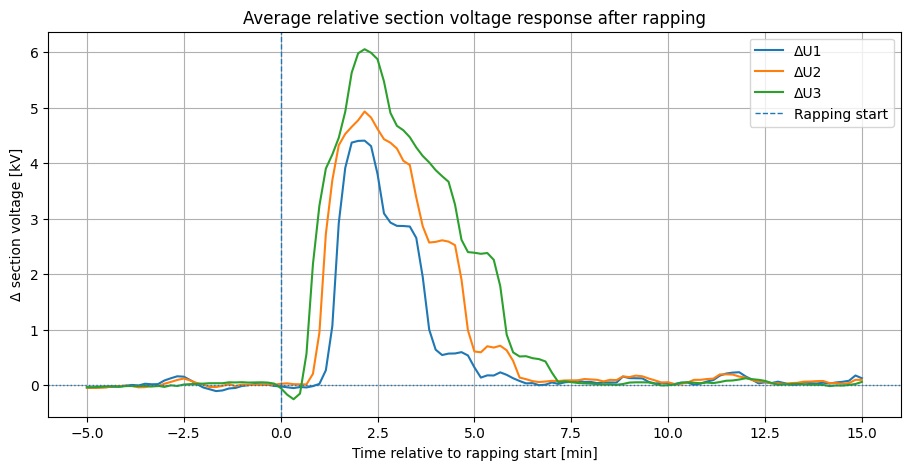

In [45]:
plt.figure(figsize=(11, 5))

plt.plot(avg_rel_response.index, avg_rel_response[U1_REL], label="ΔU1")
plt.plot(avg_rel_response.index, avg_rel_response[U2_REL], label="ΔU2")
plt.plot(avg_rel_response.index, avg_rel_response[U3_REL], label="ΔU3")

plt.axvline(0, linestyle="--", linewidth=1, label="Rapping start")
plt.axhline(0, linestyle=":", linewidth=1)

plt.xlabel("Time relative to rapping start [min]")
plt.ylabel("Δ section voltage [kV]")
plt.title("Average relative section voltage response after rapping")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
section_tail_rows = []

for event_id, group in events_rel_df.groupby("event_id"):
    after = group[(group["t_rel_min"] >= 0) & (group["t_rel_min"] <= 15)].copy()
    
    if len(after) == 0:
        continue
    
    dust_rel = after[TARGET_COL + "_rel"]
    sample_hours = 10 / 3600
    
    tail_mask = dust_rel <= TAIL_DUST_THRESHOLD_MG
    
    row = {
        "event_id": event_id,
        "tail_energy_P1_kwh": after[P1_REL].where(tail_mask, 0).clip(lower=0).sum() * sample_hours,
        "tail_energy_P2_kwh": after[P2_REL].where(tail_mask, 0).clip(lower=0).sum() * sample_hours,
        "tail_energy_P3_kwh": after[P3_REL].where(tail_mask, 0).clip(lower=0).sum() * sample_hours,
    }
    
    row["tail_energy_sections_sum_kwh"] = (
        row["tail_energy_P1_kwh"]
        + row["tail_energy_P2_kwh"]
        + row["tail_energy_P3_kwh"]
    )
    
    section_tail_rows.append(row)

section_tail_energy = pd.DataFrame(section_tail_rows)

typical_event_analysis = typical_event_analysis.merge(
    section_tail_energy,
    on="event_id",
    how="left"
)

typical_event_analysis[
    [
        "tail_energy_P1_kwh",
        "tail_energy_P2_kwh",
        "tail_energy_P3_kwh",
        "tail_energy_sections_sum_kwh",
        "tail_energy_kwh_0_15min",
    ]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,tail_energy_P1_kwh,tail_energy_P2_kwh,tail_energy_P3_kwh,tail_energy_sections_sum_kwh,tail_energy_kwh_0_15min
count,412.000000,412.000000,412.000000,412.000000,412.000000
mean,0.207410,0.295812,0.456292,0.959514,0.930476
std,0.171144,0.205244,0.273388,0.639575,0.642136
min,0.000000,0.001111,0.000000,0.005556,0.000000
25%,0.063361,0.175033,0.266222,0.528833,0.500886
50%,0.154506,0.255489,0.384856,0.786867,0.754200
75%,0.325475,0.411936,0.634681,1.370192,1.345933
90%,0.425967,0.498402,0.756889,1.678136,1.566762
95%,0.527705,0.733069,0.951444,2.239046,2.210100
max,0.897033,0.877611,1.198056,2.574656,2.550622


In [47]:
eps = 1e-9

typical_event_analysis["tail_share_P1"] = (
    typical_event_analysis["tail_energy_P1_kwh"]
    / (typical_event_analysis["tail_energy_sections_sum_kwh"] + eps)
)

typical_event_analysis["tail_share_P2"] = (
    typical_event_analysis["tail_energy_P2_kwh"]
    / (typical_event_analysis["tail_energy_sections_sum_kwh"] + eps)
)

typical_event_analysis["tail_share_P3"] = (
    typical_event_analysis["tail_energy_P3_kwh"]
    / (typical_event_analysis["tail_energy_sections_sum_kwh"] + eps)
)

typical_event_analysis[
    ["tail_share_P1", "tail_share_P2", "tail_share_P3"]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,tail_share_P1,tail_share_P2,tail_share_P3
count,412.000000,412.000000,412.000000
mean,0.218935,0.301189,0.479875
std,0.152432,0.084236,0.164023
min,0.000000,0.008066,0.000000
25%,0.143544,0.289267,0.453462
50%,0.225234,0.306872,0.477745
75%,0.241469,0.324973,0.532043
90%,0.322126,0.346867,0.683336
95%,0.600459,0.361615,0.731447
max,0.978503,0.973318,0.952335


In [48]:
section_share_mean = typical_event_analysis[
    ["tail_share_P1", "tail_share_P2", "tail_share_P3"]
].mean()

section_share_median = typical_event_analysis[
    ["tail_share_P1", "tail_share_P2", "tail_share_P3"]
].median()

section_share_df = pd.DataFrame({
    "mean_share": section_share_mean,
    "median_share": section_share_median,
})

section_share_df

,mean_share,median_share
tail_share_P1,0.218935,0.225234
tail_share_P2,0.301189,0.306872
tail_share_P3,0.479875,0.477745


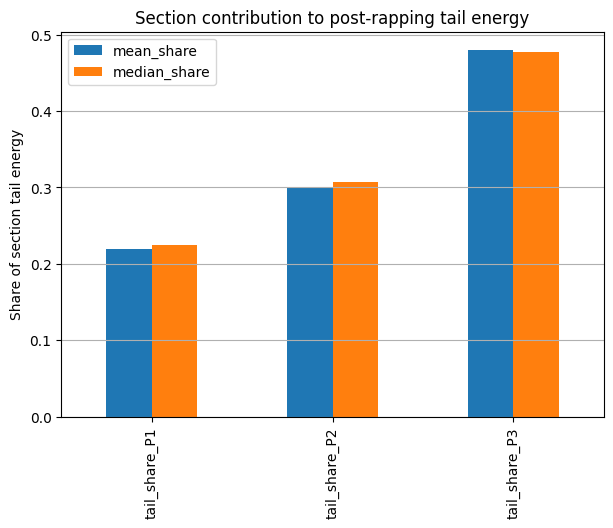

In [49]:
section_share_df.plot(kind="bar", figsize=(7, 5))
plt.ylabel("Share of section tail energy")
plt.title("Section contribution to post-rapping tail energy")
plt.grid(axis="y")
plt.show()

In [50]:
# Total monthly tail-energy summary for all and typical rapping events

def summarize_tail_energy(events_df, label):
    total_events = len(events_df)

    total_extra_energy = events_df["extra_energy_kwh_0_15min"].sum()
    total_tail_energy = events_df["tail_energy_kwh_0_15min"].sum()

    median_extra_energy = events_df["extra_energy_kwh_0_15min"].median()
    median_tail_energy = events_df["tail_energy_kwh_0_15min"].median()

    mean_extra_energy = events_df["extra_energy_kwh_0_15min"].mean()
    mean_tail_energy = events_df["tail_energy_kwh_0_15min"].mean()

    total_tail_share = total_tail_energy / total_extra_energy if total_extra_energy > 0 else np.nan

    return {
        "dataset": label,
        "n_events": total_events,
        "total_extra_energy_kwh": total_extra_energy,
        "total_tail_energy_kwh": total_tail_energy,
        "total_tail_energy_share": total_tail_share,
        "mean_extra_energy_kwh_per_event": mean_extra_energy,
        "mean_tail_energy_kwh_per_event": mean_tail_energy,
        "median_extra_energy_kwh_per_event": median_extra_energy,
        "median_tail_energy_kwh_per_event": median_tail_energy,
    }


monthly_tail_summary = pd.DataFrame([
    summarize_tail_energy(event_analysis, "all_events"),
    summarize_tail_energy(typical_event_analysis, "typical_events"),
])

monthly_tail_summary

,dataset,n_events,total_extra_energy_kwh,total_tail_energy_kwh,total_tail_energy_share,mean_extra_energy_kwh_per_event,mean_tail_energy_kwh_per_event,median_extra_energy_kwh_per_event,median_tail_energy_kwh_per_event
0,all_events,423,666.119376,475.430977,0.713732,1.574750,1.123950,1.141944,0.779878
1,typical_events,412,545.069765,383.356177,0.703316,1.322985,0.930476,1.106578,0.754200


In [51]:
energy_prices_pln_per_kwh = [0.5, 0.8, 1.0, 1.5]

cost_rows = []

for _, row in monthly_tail_summary.iterrows():
    for price in energy_prices_pln_per_kwh:
        cost_rows.append({
            "dataset": row["dataset"],
            "energy_price_pln_per_kwh": price,
            "total_extra_energy_cost_pln": row["total_extra_energy_kwh"] * price,
            "total_tail_energy_cost_pln": row["total_tail_energy_kwh"] * price,
        })

monthly_tail_cost = pd.DataFrame(cost_rows)
monthly_tail_cost

,dataset,energy_price_pln_per_kwh,total_extra_energy_cost_pln,total_tail_energy_cost_pln
0,all_events,0.5,333.059688,237.715488
1,all_events,0.8,532.895501,380.344782
2,all_events,1.0,666.119376,475.430977
3,all_events,1.5,999.179064,713.146465
4,typical_events,0.5,272.534882,191.678088
5,typical_events,0.8,436.055812,306.684941
6,typical_events,1.0,545.069765,383.356177
7,typical_events,1.5,817.604647,575.034265


In [52]:
data_duration_days = (df_eco.index.max() - df_eco.index.min()).total_seconds() / (24 * 3600)
data_duration_days

32.0

In [53]:
annual_factor = 365 / data_duration_days

annual_tail_summary = monthly_tail_summary.copy()
annual_tail_summary["data_duration_days"] = data_duration_days
annual_tail_summary["annual_factor"] = annual_factor

annual_tail_summary["annual_extra_energy_kwh_est"] = (
    annual_tail_summary["total_extra_energy_kwh"] * annual_factor
)

annual_tail_summary["annual_tail_energy_kwh_est"] = (
    annual_tail_summary["total_tail_energy_kwh"] * annual_factor
)

annual_tail_summary

,dataset,n_events,total_extra_energy_kwh,total_tail_energy_kwh,total_tail_energy_share,mean_extra_energy_kwh_per_event,mean_tail_energy_kwh_per_event,median_extra_energy_kwh_per_event,median_tail_energy_kwh_per_event,data_duration_days,annual_factor,annual_extra_energy_kwh_est,annual_tail_energy_kwh_est
0,all_events,423,666.119376,475.430977,0.713732,1.574750,1.123950,1.141944,0.779878,32.0,11.40625,7597.924130,5422.884580
1,typical_events,412,545.069765,383.356177,0.703316,1.322985,0.930476,1.106578,0.754200,32.0,11.40625,6217.202004,4372.656392


In [54]:
annual_cost_rows = []

for _, row in annual_tail_summary.iterrows():
    for price in energy_prices_pln_per_kwh:
        annual_cost_rows.append({
            "dataset": row["dataset"],
            "energy_price_pln_per_kwh": price,
            "annual_extra_energy_cost_pln_est": row["annual_extra_energy_kwh_est"] * price,
            "annual_tail_energy_cost_pln_est": row["annual_tail_energy_kwh_est"] * price,
        })

annual_tail_cost = pd.DataFrame(annual_cost_rows)
annual_tail_cost

,dataset,energy_price_pln_per_kwh,annual_extra_energy_cost_pln_est,annual_tail_energy_cost_pln_est
0,all_events,0.5,3798.962065,2711.442290
1,all_events,0.8,6078.339304,4338.307664
2,all_events,1.0,7597.924130,5422.884580
3,all_events,1.5,11396.886195,8134.326870
4,typical_events,0.5,3108.601002,2186.328196
5,typical_events,0.8,4973.761603,3498.125114
6,typical_events,1.0,6217.202004,4372.656392
7,typical_events,1.5,9325.803006,6558.984588


In [55]:
reduction_scenarios = [0.10, 0.25, 0.50, 0.75]

scenario_rows = []

for _, row in annual_tail_summary.iterrows():
    for reduction in reduction_scenarios:
        for price in energy_prices_pln_per_kwh:
            scenario_rows.append({
                "dataset": row["dataset"],
                "tail_reduction_fraction": reduction,
                "energy_price_pln_per_kwh": price,
                "annual_energy_saving_kwh_est": row["annual_tail_energy_kwh_est"] * reduction,
                "annual_cost_saving_pln_est": row["annual_tail_energy_kwh_est"] * reduction * price,
            })

saving_scenarios = pd.DataFrame(scenario_rows)
saving_scenarios

,dataset,tail_reduction_fraction,energy_price_pln_per_kwh,annual_energy_saving_kwh_est,annual_cost_saving_pln_est
0,all_events,0.10,0.5,542.288458,271.144229
1,all_events,0.10,0.8,542.288458,433.830766
2,all_events,0.10,1.0,542.288458,542.288458
3,all_events,0.10,1.5,542.288458,813.432687
4,all_events,0.25,0.5,1355.721145,677.860573
5,all_events,0.25,0.8,1355.721145,1084.576916
6,all_events,0.25,1.0,1355.721145,1355.721145
7,all_events,0.25,1.5,1355.721145,2033.581718
8,all_events,0.50,0.5,2711.442290,1355.721145
9,all_events,0.50,0.8,2711.442290,2169.153832


In [56]:
typical_annual = annual_tail_summary[
    annual_tail_summary["dataset"] == "typical_events"
].iloc[0]

compact_summary = pd.DataFrame({
    "metric": [
        "Number of typical rapping events in dataset",
        "Dataset duration [days]",
        "Total additional post-rapping energy [kWh/month]",
        "Total tail energy [kWh/month]",
        "Tail energy share [-]",
        "Estimated annual tail energy [kWh/year]",
    ],
    "value": [
        typical_annual["n_events"],
        typical_annual["data_duration_days"],
        typical_annual["total_extra_energy_kwh"],
        typical_annual["total_tail_energy_kwh"],
        typical_annual["total_tail_energy_share"],
        typical_annual["annual_tail_energy_kwh_est"],
    ]
})

compact_summary

,metric,value
0,Number of typical rapping events in dataset,412.000000
1,Dataset duration [days],32.000000
2,Total additional post-rapping energy [kWh/month],545.069765
3,Total tail energy [kWh/month],383.356177
4,Tail energy share [-],0.703316
5,Estimated annual tail energy [kWh/year],4372.656392
